In [1092]:
import pandas as pd
import numpy as np
# from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


In [1093]:
data = pd.read_csv('./data/Etapa1DatosEstudiantes.csv' , delimiter=';')

In [1094]:
df = data.copy()

In [1095]:
df.shape

(1161, 19)

In [1096]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1161 entries, 0 to 1160
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Id                          1161 non-null   int64  
 1   Sexo                        1161 non-null   str    
 2   Edad                        1160 non-null   float64
 3   MiembrosFamilia             1160 non-null   float64
 4   ViveConPadres               1142 non-null   str    
 5   TrabajoMama                 1159 non-null   str    
 6   TrabajoPapa                 1159 non-null   str    
 7   Cuidador                    1158 non-null   str    
 8   TiempoDedicadoEstudioNum    1158 non-null   float64
 9   ApoyoEscolar                1153 non-null   str    
 10  ApoyoEscolarFamilia         1146 non-null   str    
 11  QuiereEstudioUniversitario  1159 non-null   str    
 12  RelacionRomantica           1159 non-null   str    
 13  CalidadRelFamilia           1159 non-null   

In [1097]:
df.describe(include='all')

,Id,Sexo,Edad,MiembrosFamilia,ViveConPadres,TrabajoMama,TrabajoPapa,Cuidador,TiempoDedicadoEstudioNum,ApoyoEscolar,ApoyoEscolarFamilia,QuiereEstudioUniversitario,RelacionRomantica,CalidadRelFamilia,TiempoLibre,SaleConAmigos,Ausencias,CantAlcPorSem,PromNotas
count,1161.000000,1161,1160.000000,1160.000000,1142,1159,1159,1158,1158.000000,1153,1146,1159,1159,1159.000000,1159.000000,1159.000000,1159.000000,1153.000000,1161.000000
unique,NaN,2,NaN,NaN,2,5,5,10,NaN,3,5,3,3,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,F,NaN,NaN,S,Otros,Otros,Mama,NaN,no,Si,Si,Si,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,645,NaN,NaN,821,356,469,601,NaN,577,651,849,477,NaN,NaN,NaN,NaN,NaN,NaN
mean,571.674419,NaN,16.671552,3.551724,NaN,NaN,NaN,NaN,4.591537,NaN,NaN,NaN,NaN,4.095772,3.827437,3.108714,7.188093,2.307025,11.244866
std,333.244669,NaN,1.774097,1.384898,NaN,NaN,NaN,NaN,4.333125,NaN,NaN,NaN,NaN,15.735848,13.956059,1.276296,11.264407,1.203768,3.245180
min,1.000000,NaN,13.000000,1.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,-4.000000,-3.000000,1.000000,0.000000,1.000000,1.330000
25%,282.000000,NaN,16.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,3.000000,2.000000,2.000000,1.000000,1.000000,9.330000
50%,572.000000,NaN,17.000000,4.000000,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN,NaN,4.000000,3.000000,3.000000,5.000000,2.000000,11.330000
75%,859.000000,NaN,18.000000,5.000000,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,4.000000,4.000000,4.000000,11.000000,3.000000,13.330000


In [1098]:
df.columns

Index(['Id', 'Sexo', 'Edad', 'MiembrosFamilia', 'ViveConPadres', 'TrabajoMama',
       'TrabajoPapa', 'Cuidador', 'TiempoDedicadoEstudioNum', 'ApoyoEscolar',
       'ApoyoEscolarFamilia', 'QuiereEstudioUniversitario',
       'RelacionRomantica', 'CalidadRelFamilia', 'TiempoLibre',
       'SaleConAmigos', 'Ausencias', 'CantAlcPorSem', 'PromNotas'],
      dtype='str')

In [1099]:
df.head(
)

,Id,Sexo,Edad,MiembrosFamilia,ViveConPadres,TrabajoMama,TrabajoPapa,Cuidador,TiempoDedicadoEstudioNum,ApoyoEscolar,ApoyoEscolarFamilia,QuiereEstudioUniversitario,RelacionRomantica,CalidadRelFamilia,TiempoLibre,SaleConAmigos,Ausencias,CantAlcPorSem,PromNotas
0,1,F,18.0,5.0,S,Educacion,Am@DeCasa,Ma,11.0,Si,Si,Si,Si,1.0,3.0,2.0,13.0,2.0,7.33
1,2,F,20.0,4.0,N,Otros,Otros,Papa,2.0,No,No,No,No,2.0,4.0,5.0,14.0,3.0,10.33
2,3,F,16.0,3.0,N,Educacion,Otros,Otros,5.0,No,No,No,No,3.0,3.0,2.0,8.0,4.0,12.33
3,3,F,16.0,3.0,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.33
4,4,F,14.0,1.0,S,Otros,Salud,Otros,14.0,No,Si,Si,No,1.0,2.0,3.0,19.0,3.0,14.00


## Limpieza

In [1100]:
columnas_categoricas = df.select_dtypes(exclude=[np.number]).columns.tolist()
display(columnas_categoricas)

['Sexo',
 'ViveConPadres',
 'TrabajoMama',
 'TrabajoPapa',
 'Cuidador',
 'ApoyoEscolar',
 'ApoyoEscolarFamilia',
 'QuiereEstudioUniversitario',
 'RelacionRomantica']

In [1101]:
for columna in columnas_categoricas:
    print(str(columna) + ":" + str(df[columna].unique()))

Sexo:<StringArray>
['F', 'M']
Length: 2, dtype: str
ViveConPadres:<StringArray>
['S', 'N', nan]
Length: 3, dtype: str
TrabajoMama:<StringArray>
['Educacion', 'Otros', nan, 'Am@DeCasa', 'Salud', 'Servicios']
Length: 6, dtype: str
TrabajoPapa:<StringArray>
['Am@DeCasa', 'Otros', nan, 'Salud', 'Servicios', 'Educacion']
Length: 6, dtype: str
Cuidador:<StringArray>
['Ma', 'Papa', 'Otros', nan, 'Mama', 'Ma ', 'Pa ', 'P', 'M', 'm', 'p ']
Length: 11, dtype: str
ApoyoEscolar:<StringArray>
['Si', 'No', nan, 'no']
Length: 4, dtype: str
ApoyoEscolarFamilia:<StringArray>
['Si', 'No', nan, 'no', 's ', 'n ']
Length: 6, dtype: str
QuiereEstudioUniversitario:<StringArray>
['Si', 'No', nan, 'no']
Length: 4, dtype: str
RelacionRomantica:<StringArray>
['Si', 'No', nan, 'no']
Length: 4, dtype: str


In [1102]:
for columna in columnas_categoricas:
    if columna != 'Sexo':
        df[columna] = (
            df[columna]
            .str.lower()
            .str.strip()
            .replace({
                's': 'si',
                'n': 'no',
                'pa': 'papa',
                'ma': 'mama',
                'p': 'papa',
                'm': 'mama'
            })
        )
        
    else:
        df[columna] = (
            df[columna]
            .str.lower()
            .str.strip()
            .replace({
                's': 'si',
                'n': 'no',
                'pa': 'papa',
                'ma': 'mama',
                'p': 'papa',
            })
        )

In [1103]:
for columna in columnas_categoricas:
    print(str(columna) + ":" + str(df[columna].unique()))

Sexo:<StringArray>
['f', 'm']
Length: 2, dtype: str
ViveConPadres:<StringArray>
['si', 'no', nan]
Length: 3, dtype: str
TrabajoMama:<StringArray>
['educacion', 'otros', nan, 'am@decasa', 'salud', 'servicios']
Length: 6, dtype: str
TrabajoPapa:<StringArray>
['am@decasa', 'otros', nan, 'salud', 'servicios', 'educacion']
Length: 6, dtype: str
Cuidador:<StringArray>
['mama', 'papa', 'otros', nan]
Length: 4, dtype: str
ApoyoEscolar:<StringArray>
['si', 'no', nan]
Length: 3, dtype: str
ApoyoEscolarFamilia:<StringArray>
['si', 'no', nan]
Length: 3, dtype: str
QuiereEstudioUniversitario:<StringArray>
['si', 'no', nan]
Length: 3, dtype: str
RelacionRomantica:<StringArray>
['si', 'no', nan]
Length: 3, dtype: str


# Calidad de los datos

## Completitud

In [1104]:
round((df.isnull().sum() / len(df))*100 , 3)

Id                            0.000
Sexo                          0.000
Edad                          0.086
MiembrosFamilia               0.086
ViveConPadres                 1.637
TrabajoMama                   0.172
TrabajoPapa                   0.172
Cuidador                      0.258
TiempoDedicadoEstudioNum      0.258
ApoyoEscolar                  0.689
ApoyoEscolarFamilia           1.292
QuiereEstudioUniversitario    0.172
RelacionRomantica             0.172
CalidadRelFamilia             0.172
TiempoLibre                   0.172
SaleConAmigos                 0.172
Ausencias                     0.172
CantAlcPorSem                 0.689
PromNotas                     0.000
dtype: float64

## Unicidad

In [1105]:
df.duplicated().sum()

np.int64(9)

In [1106]:
df = df.drop_duplicates()

In [1107]:
df.duplicated().sum()

np.int64(0)

## Consistencia

In [1108]:
cuidadores = df[(df["ViveConPadres"] == "si") & (~df["Cuidador"].isin(["mama","papa"]))]
display(cuidadores['Cuidador'].unique())

<StringArray>
['otros', nan]
Length: 2, dtype: str

## Validez

In [1109]:
df = df[(df['CalidadRelFamilia'].between(1,5)) | (df['CalidadRelFamilia'].isna())]

df = df[(df['TiempoLibre'].between(1,5)) | (df['TiempoLibre'].isna())]

df = df[(df['SaleConAmigos'].between(1,5)) | (df['SaleConAmigos'].isna())]

df = df[
    (df['Ausencias'] >= 0) | (df['Ausencias'].isna())
]

df = df[
    (df['PromNotas'] >= 0) | (df['PromNotas'].isna())
]

df = df[
    (df['TiempoDedicadoEstudioNum'] >= 0) | (df['TiempoDedicadoEstudioNum'].isna())
]

# Transformaciones Previas Al Pipeline

In [1110]:
df = df.drop(columns=["Id"])

In [1111]:
((df.isnull().sum()/df.shape[0])).sort_values(ascending=False)

ViveConPadres                 0.016637
ApoyoEscolarFamilia           0.013135
CantAlcPorSem                 0.007005
ApoyoEscolar                  0.007005
Cuidador                      0.002627
TiempoDedicadoEstudioNum      0.002627
TrabajoMama                   0.001751
TrabajoPapa                   0.001751
QuiereEstudioUniversitario    0.001751
RelacionRomantica             0.001751
CalidadRelFamilia             0.001751
TiempoLibre                   0.001751
SaleConAmigos                 0.001751
Ausencias                     0.001751
MiembrosFamilia               0.000876
Edad                          0.000876
Sexo                          0.000000
PromNotas                     0.000000
dtype: float64

In [1112]:
df = df.dropna(subset=['CantAlcPorSem'])

# Pipeline Regresión Lineal

In [1113]:
X = df.drop('CantAlcPorSem', axis=1)
y = df['CantAlcPorSem']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

<Axes: >

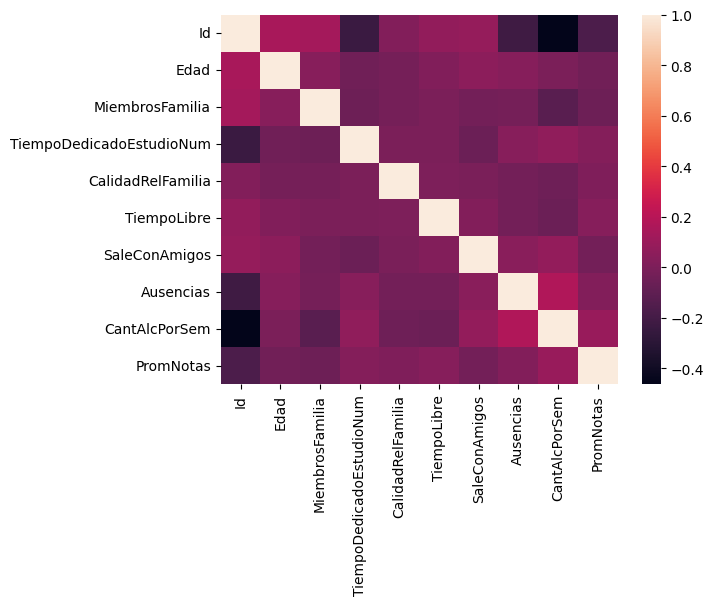

In [1114]:
sns.heatmap(data.corr(numeric_only=True))

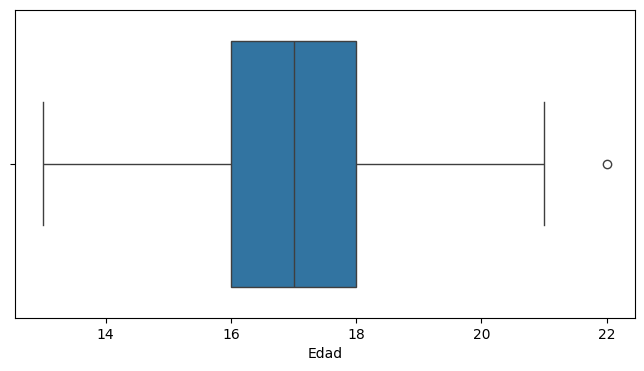

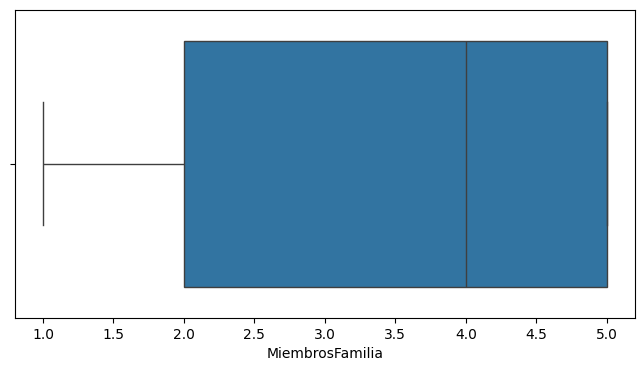

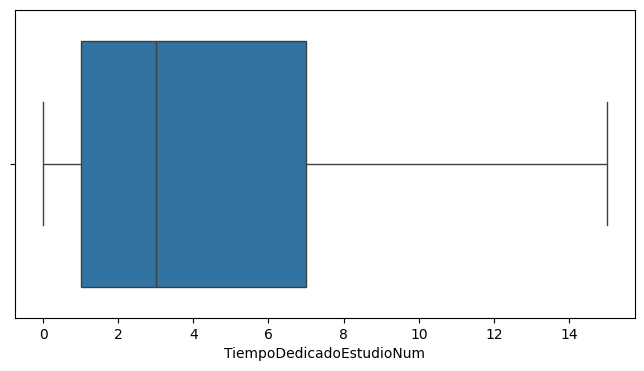

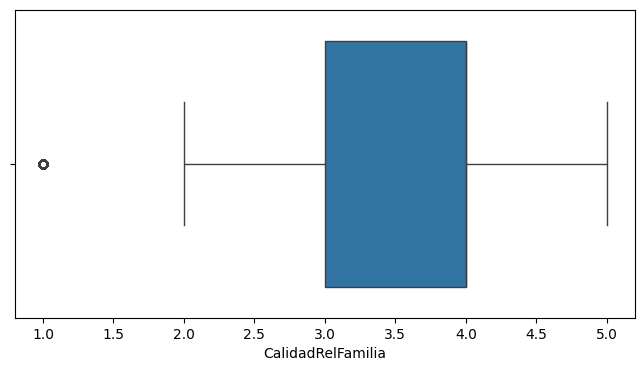

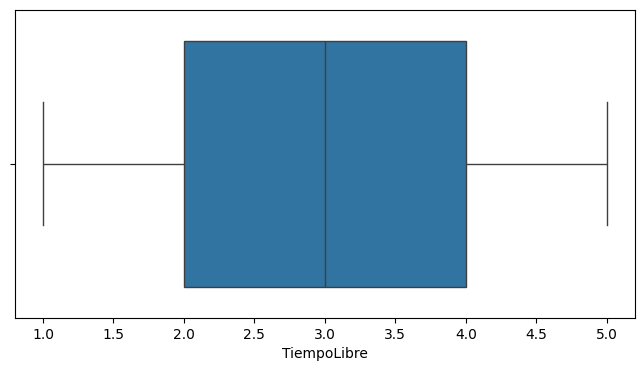

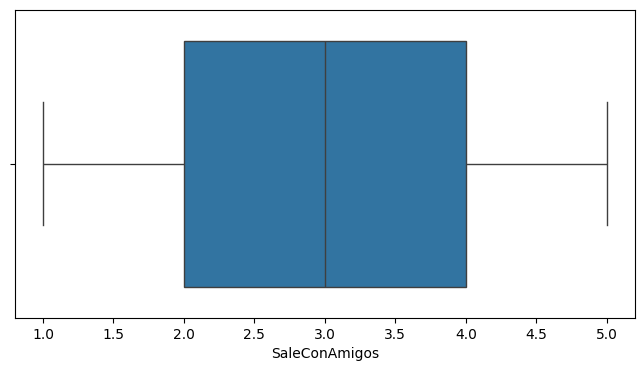

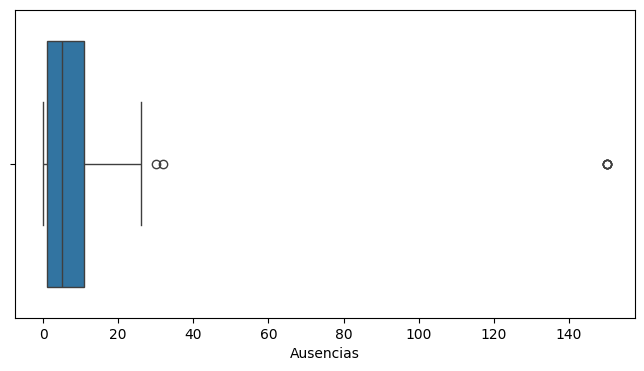

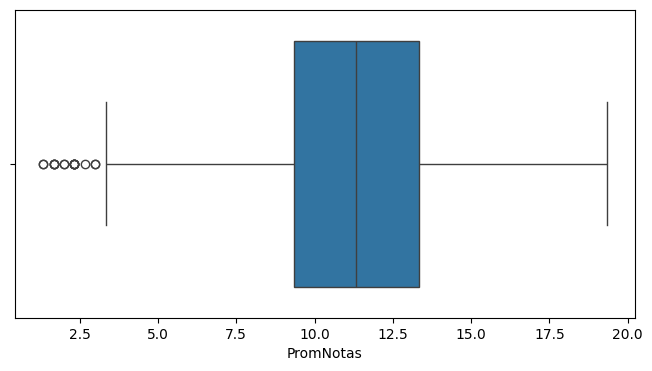

In [1115]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.show()

Como no hay muchos outliers entonces se usa MinMax

In [1116]:
df[categorical_cols] = df[categorical_cols].fillna("desconocido")

In [1117]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [1118]:
def limpiar_ausencias (df):
    df = df.copy()
    col = 'Ausencias'
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)
    return df

In [1119]:
limpiar_ausencias_transformer = FunctionTransformer(limpiar_ausencias)

In [1120]:
pipeline_linear_regresion = Pipeline(steps=[
    ("limpiar_ausencias", limpiar_ausencias_transformer),
    ("preprocesamiento", preprocessor),
    ("modelo", LinearRegression())
])

### Validación del modelo

In [1121]:
pipeline_linear_regresion

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('limpiar_ausencias', ...), ('preprocesamiento', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function lim...t 0x1221345c0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keywo

In [1122]:
pipeline_linear_regresion.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('limpiar_ausencias', ...), ('preprocesamiento', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function lim...t 0x1221345c0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keywo

In [1123]:
y_train_pred_linear = pipeline_linear_regresion.predict(X_train)
y_test_pred_linear  = pipeline_linear_regresion.predict(X_test)

rmse_linear_train = np.sqrt(mean_squared_error(y_train, y_train_pred_linear))
mae_linear_train  = mean_absolute_error(y_train, y_train_pred_linear)
r2_linear_train   = r2_score(y_train, y_train_pred_linear)

rmse_linear_test = np.sqrt(mean_squared_error(y_test, y_test_pred_linear))
mae_linear_test  = mean_absolute_error(y_test, y_test_pred_linear)
r2_linear_test   = r2_score(y_test, y_test_pred_linear)

print("===== LINEAR REGRESSION =====")

print("\n--- Train ---")
print(f"RMSE: {rmse_linear_train:.3f}")
print(f"MAE : {mae_linear_train:.3f}")
print(f"R²  : {r2_linear_train:.3f}")

print("\n--- Test ---")
print(f"RMSE: {rmse_linear_test:.3f}")
print(f"MAE : {mae_linear_test:.3f}")
print(f"R²  : {r2_linear_test:.3f}")

===== LINEAR REGRESSION =====

--- Train ---
RMSE: 1.033
MAE : 0.844
R²  : 0.270

--- Test ---
RMSE: 1.044
MAE : 0.830
R²  : 0.228


### Estimación de la capacidad del modelo

# Pipeline Regresión Polinomial

In [1124]:
numeric_transformer_poly = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ("poly", PolynomialFeatures(degree=2, include_bias=False))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [1125]:
pipeline_poly_regresion = Pipeline(steps=[
    ("limpiar_ausencias", limpiar_ausencias_transformer),
    ("preprocesamiento", preprocessor_poly),
    ("modelo", LinearRegression()),
])

In [1126]:
param_grid_poly = {
    "preprocesamiento__num__poly__degree": [1,2,3]
}

In [1127]:
gridSearch = GridSearchCV(
    estimator=pipeline_poly_regresion,
    param_grid=param_grid_poly,
    cv=5,
)

In [1128]:
gridSearch.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'preprocesamiento__num__poly__degree': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the

In [1129]:
mejor_modelo_poly = gridSearch.best_estimator_
print("Best params", gridSearch.best_params_)

Best params {'preprocesamiento__num__poly__degree': 1}


In [1130]:
y_train_pred_poly = mejor_modelo_poly.predict(X_train)
y_test_pred_poly  = mejor_modelo_poly.predict(X_test)

rmse_poly_train = np.sqrt(mean_squared_error(y_train, y_train_pred_poly))
mae_poly_train  = mean_absolute_error(y_train, y_train_pred_poly)
r2_poly_train   = r2_score(y_train, y_train_pred_poly)

rmse_poly_test = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))
mae_poly_test  = mean_absolute_error(y_test, y_test_pred_poly)
r2_poly_test   = r2_score(y_test, y_test_pred_poly)

print("===== POLY REGRESSION =====")

print("\n--- Train ---")
print(f"RMSE: {rmse_poly_train:.3f}")
print(f"MAE : {mae_poly_train:.3f}")
print(f"R²  : {r2_poly_train:.3f}")

print("\n--- Test ---")
print(f"RMSE: {rmse_poly_test:.3f}")
print(f"MAE : {mae_poly_test:.3f}")
print(f"R²  : {r2_poly_test:.3f}")

===== POLY REGRESSION =====

--- Train ---
RMSE: 1.033
MAE : 0.844
R²  : 0.270

--- Test ---
RMSE: 1.044
MAE : 0.830
R²  : 0.228


# Clasificación

In [1131]:
pipeline_rl = Pipeline(steps=[
    ('preprocesador', preprocessor),
    ('modelo', LogisticRegression(
        max_iter=1000,
     ))
])

In [1132]:
param_grid_rl = [
    {
        'modelo__penalty': ['l2'],
        'modelo__solver': ['newton-cg', 'lbfgs', 'liblinear'],
        'modelo__C': [0.1, 0.2, 0.5, 0.8, 1]
    },
    {
        'modelo__penalty': ['l1'],
        'modelo__solver': ['liblinear'],
        'modelo__C': [0.1, 0.2, 0.5, 0.8, 1]
    }
]

In [1133]:
grid_rl = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=param_grid_rl,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [1134]:
grid_rl.fit(X_train, y_train)

/Users/mattia/Library/Mobile Documents/com~apple~CloudDocs/UNIANDES/git/MaterialDeClase-ISIS-2611-1/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/mattia/Library/Mobile Documents/com~apple~CloudDocs/UNIANDES/git/MaterialDeClase-ISIS-2611-1/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/mattia/Library/

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'modelo__C': [0.1, 0.2, ...], 'modelo__penalty': ['l2'], 'modelo__solver': ['newton-cg', 'lbfgs', ...]}, {'modelo__C': [0.1, 0.2, ...], 'modelo__penalty': ['l1'], 'modelo__solver': ['liblinear']}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher

In [1135]:
mejor_modelo_rl = grid_rl.best_estimator_

In [1136]:
y_pred_rl_train = mejor_modelo_rl.predict(X_train)
y_pred_rl_test = mejor_modelo_rl.predict(X_test)

In [1139]:
print(classification_report(y_test, y_pred_rl_test))

              precision    recall  f1-score   support

         1.0       0.57      0.82      0.67        66
         2.0       0.30      0.35      0.32        63
         3.0       0.31      0.18      0.23        49
         4.0       0.34      0.25      0.29        40
         5.0       0.00      0.00      0.00         9

    accuracy                           0.42       227
   macro avg       0.30      0.32      0.30       227
weighted avg       0.38      0.42      0.39       227

